# E-commerce Sales Analysis — 2023

**A configurable business-intelligence analysis of e-commerce sales.**

This notebook analyses delivered-order revenue and customer experience for a
configurable period (by default the full year **2023**, compared against
**2022**). It is a refactor of the original exploratory notebook: the same
metrics and charts, reorganised into clear sections with reusable, documented
code in `data_loader.py` and `business_metrics.py`.

---

## Table of Contents

1. [Introduction & Business Objectives](#1)
2. [Data Loading & Configuration](#2)
3. [Data Preparation & Transformation](#3)
4. [Business Metrics Calculation](#4)
   - 4.1 [Revenue Analysis](#4-1)
   - 4.2 [Product Analysis](#4-2)
   - 4.3 [Geographic Analysis](#4-3)
   - 4.4 [Customer Experience Analysis](#4-4)
5. [Summary of Observations](#5)


<a id="1"></a>
## 1. Introduction & Business Objectives

The business wants to understand how the online store performed over a given
period and how that compares to the same period a year earlier. Specifically:

- **Revenue**: How much revenue did we generate, and how is it trending
  month-over-month? How does it compare to last year?
- **Products**: Which product categories drive the most revenue?
- **Geography**: Which states are our strongest markets?
- **Customer experience**: How satisfied are customers, and does delivery
  speed affect their ratings?

All revenue figures are based on **delivered** orders only (orders that were
cancelled, returned or still in transit do not represent realised revenue).

### Data dictionary

| Field | Source | Meaning |
|---|---|---|
| `order_id` | orders | Unique identifier of an order |
| `order_item_id` | order_items | Line-item number within an order |
| `product_id` | order_items | Product purchased |
| `price` | order_items | Item price in USD (revenue is the sum of prices) |
| `order_status` | orders | Lifecycle status; we keep `delivered` |
| `purchase_timestamp` | orders | When the order was placed |
| `delivered_customer_date` | orders | When the order reached the customer |
| `product_category_name` | products | Product category (e.g. `electronics`) |
| `customer_state` | customers | US state of the customer (2-letter code) |
| `review_score` | reviews | Customer rating from 1 (worst) to 5 (best) |
| `purchase_year` / `purchase_month` | derived | Calendar year / month of purchase |
| `delivery_days` | derived | Days from purchase to delivery |

**Business terms.** *Revenue* = sum of delivered item prices. *AOV* (average
order value) = average revenue per order. *Month-over-month growth* = percentage
change in monthly revenue. *High satisfaction* = share of orders rated 4 or 5.


<a id="2"></a>
## 2. Data Loading & Configuration

All loading and cleaning lives in `data_loader.py`. The analysis period is
controlled by the configuration block below — change `ANALYSIS_YEAR`,
`COMPARISON_YEAR` or `ANALYSIS_MONTH` to analyse a different period without
touching any other code.


In [1]:
import calendar

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import plotly.express as px

import data_loader as dl
import business_metrics as bm

# --- Analysis configuration -------------------------------------------------
DATA_PATH = "ecommerce_data/"
ANALYSIS_YEAR = 2023        # Year to analyse
COMPARISON_YEAR = 2022      # Year to compare against (set to None to skip)
ANALYSIS_MONTH = None       # Specific month 1-12, or None for the full year

# --- Consistent, business-oriented colour scheme ----------------------------
COLOR_PRIMARY = "#1f4e79"    # deep blue   - current period
COLOR_COMPARISON = "#c55a11" # warm orange - comparison period
COLOR_ACCENT = "#2e75b6"     # mid blue    - categorical bars
SEQUENTIAL_SCALE = "Blues"   # choropleth / heatmaps

plt.rcParams.update({"figure.figsize": (11, 5), "axes.grid": True,
                     "grid.alpha": 0.3, "axes.spines.top": False,
                     "axes.spines.right": False})

# Human-readable label for the selected period, e.g. "2023" or "Mar 2023".
PERIOD_LABEL = (f"{calendar.month_abbr[ANALYSIS_MONTH]} {ANALYSIS_YEAR}"
                if ANALYSIS_MONTH else str(ANALYSIS_YEAR))
DATE_RANGE = (PERIOD_LABEL if ANALYSIS_MONTH
              else f"Jan-Dec {ANALYSIS_YEAR}")
print(f"Analysis period: {PERIOD_LABEL}"
      + (f"  |  Comparison: {COMPARISON_YEAR}" if COMPARISON_YEAR else ""))

Matplotlib is building the font cache; this may take a moment.


Analysis period: 2023  |  Comparison: 2022


In [2]:
# Load, clean and join all raw tables into one analysis-ready sales table.
sales = dl.load_sales_data(DATA_PATH)
print(f"Delivered order-items loaded: {len(sales):,}")
sales.head()

Delivered order-items loaded: 15,095


,order_id,order_item_id,product_id,price,customer_id,order_status,purchase_timestamp,delivered_customer_date,product_category_name,customer_state,customer_city,review_score,purchase_year,purchase_month,delivery_days
0,ord_5fa044951857e02fd1347b47,1,prod_9b6f1793388ae983f852d189,111.91,cust_2d36e4b647be13c15df550af,delivered,2023-04-24 13:05:32.579655,2023-05-01 02:05:32.579655,grocery_gourmet_food,TN,Knoxville,5.0,2023,4,6
1,ord_5fa044951857e02fd1347b47,2,prod_c7b5997a4d0061a9f50e874c,878.42,cust_2d36e4b647be13c15df550af,delivered,2023-04-24 13:05:32.579655,2023-05-01 02:05:32.579655,electronics,TN,Knoxville,5.0,2023,4,6
2,ord_0a02a8a1d3d282380ed7d0cc,1,prod_d5f7b6e420ea5cffc504ab21,1030.31,cust_157f0ea0316c546ac08dae30,delivered,2022-05-15 07:51:22.471390,2022-05-23 01:51:22.471390,home_garden,IL,Rockford,NaN,2022,5,7
3,ord_0a02a8a1d3d282380ed7d0cc,2,prod_01b00f21c2758bf94f51234f,1299.50,cust_157f0ea0316c546ac08dae30,delivered,2022-05-15 07:51:22.471390,2022-05-23 01:51:22.471390,home_garden,IL,Rockford,NaN,2022,5,7
4,ord_8a243422e3ad7ab97a1fe175,1,prod_a904d724d4b2b8f571e66f19,1307.04,cust_bd21648bc4c95ae7aad6bda7,delivered,2022-04-18 15:02:44.122280,2022-04-30 16:02:44.122280,home_garden,MI,Detroit,3.0,2022,4,12


<a id="3"></a>
## 3. Data Preparation & Transformation

`data_loader.build_sales_dataset` (called above via `load_sales_data`) performs
all preparation in one place:

- Parses order timestamps to proper `datetime` values.
- Keeps only **delivered** orders.
- Joins product category, customer state and review score onto each order item
  (reviews are de-duplicated to one score per order and left-joined, so revenue
  rows are never dropped or inflated).
- Derives `purchase_year`, `purchase_month` and `delivery_days`.

This replaces the original notebook's repeated, in-place merges (which raised
`SettingWithCopyWarning`) with a single, tested transformation. We now filter to
the configured period using the general-purpose `filter_period` helper.


In [3]:
# Filter to the configured analysis period and (optionally) the comparison period.
current = dl.filter_period(sales, year=ANALYSIS_YEAR, month=ANALYSIS_MONTH)
previous = (dl.filter_period(sales, year=COMPARISON_YEAR, month=ANALYSIS_MONTH)
            if COMPARISON_YEAR else None)

print(f"{PERIOD_LABEL}: {len(current):,} order-items, "
      f"{bm.total_orders(current):,} orders")
if previous is not None:
    print(f"{COMPARISON_YEAR}: {len(previous):,} order-items, "
          f"{bm.total_orders(previous):,} orders")

2023: 7,448 order-items, 4,635 orders
2022: 7,641 order-items, 4,749 orders


<a id="4"></a>
## 4. Business Metrics Calculation

Every metric is computed by a documented function in `business_metrics.py`, so
the notebook stays focused on *displaying* results. All functions accept the
filtered `current` table, making them reusable for any configured period.


<a id="4-1"></a>
### 4.1 Revenue Analysis

Headline revenue KPIs, the month-over-month trend, and year-over-year
comparison.


In [4]:
revenue = bm.total_revenue(current)
orders = bm.total_orders(current)
aov = bm.average_order_value(current)
avg_growth = bm.average_monthly_growth(current)

print(f"Total revenue ({PERIOD_LABEL}): ${revenue:,.2f}")
print(f"Total orders:                {orders:,}")
print(f"Average order value:         ${aov:,.2f}")
print(f"Average month-over-month growth: {avg_growth:+.2f}%")

if previous is not None:
    print("\nYear-over-year vs", COMPARISON_YEAR)
    print(f"  Revenue growth: {bm.pct_change(revenue, bm.total_revenue(previous)):+.2f}%")
    print(f"  Orders growth:  {bm.pct_change(orders, bm.total_orders(previous)):+.2f}%")
    print(f"  AOV growth:     {bm.pct_change(aov, bm.average_order_value(previous)):+.2f}%")

Total revenue (2023): $3,360,294.74
Total orders:                4,635
Average order value:         $724.98
Average month-over-month growth: -0.39%

Year-over-year vs 2022
  Revenue growth: -2.46%
  Orders growth:  -2.40%
  AOV growth:     -0.06%


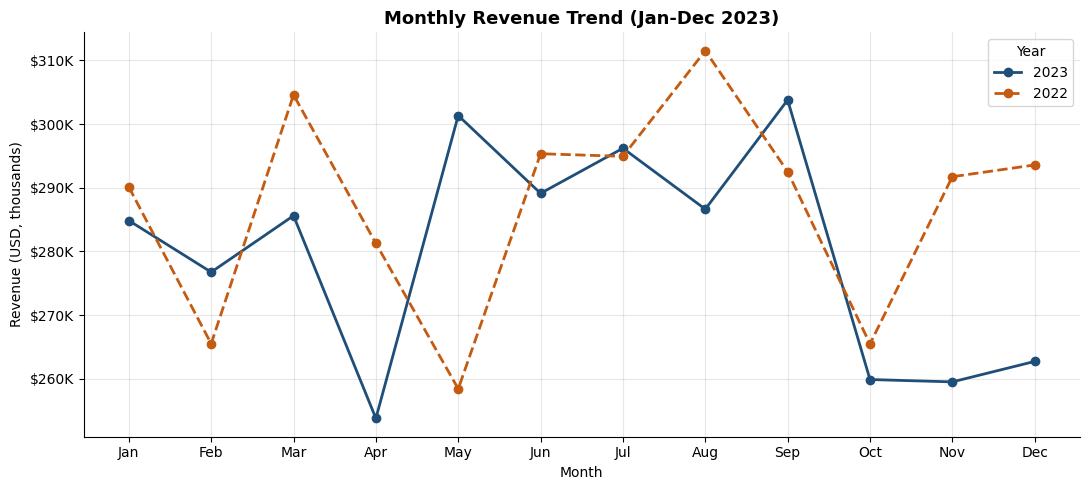

In [5]:
# Monthly revenue trend (current period, with comparison overlay when full-year).
monthly = bm.monthly_revenue(current)
month_labels = [calendar.month_abbr[m] for m in monthly.index]

fig, ax = plt.subplots()
ax.plot(month_labels, monthly.values / 1_000, marker="o",
        color=COLOR_PRIMARY, linewidth=2, label=str(ANALYSIS_YEAR))

if previous is not None and ANALYSIS_MONTH is None:
    monthly_prev = bm.monthly_revenue(previous)
    ax.plot([calendar.month_abbr[m] for m in monthly_prev.index],
            monthly_prev.values / 1_000, marker="o", linestyle="--",
            color=COLOR_COMPARISON, linewidth=2, label=str(COMPARISON_YEAR))
    ax.legend(title="Year")

ax.set_title(f"Monthly Revenue Trend ({DATE_RANGE})", fontsize=13, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue (USD, thousands)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v:,.0f}K"))
plt.tight_layout()
plt.show()

<a id="4-2"></a>
### 4.2 Product Analysis

Revenue by product category, ranked, to identify the categories that drive the
business.


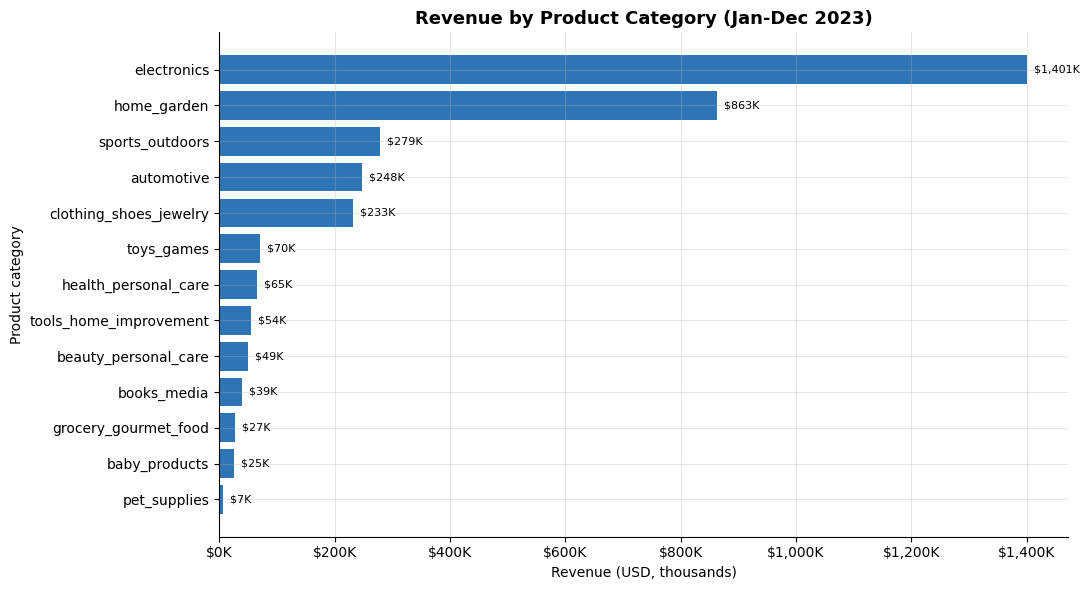

Top categories by revenue share:
product_category_name
electronics               41.7
home_garden               25.7
sports_outdoors            8.3
automotive                 7.4
clothing_shoes_jewelry     6.9


In [6]:
category_revenue = bm.revenue_by_category(current)
category_share = bm.category_revenue_share(current)

fig, ax = plt.subplots(figsize=(11, 6))
order = category_revenue.sort_values()  # ascending so largest is on top
ax.barh(order.index, order.values / 1_000, color=COLOR_ACCENT)
ax.set_title(f"Revenue by Product Category ({DATE_RANGE})",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Revenue (USD, thousands)")
ax.set_ylabel("Product category")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v:,.0f}K"))
for y, value in enumerate(order.values):
    ax.text(value / 1_000, y, f"  ${value/1_000:,.0f}K", va="center", fontsize=8)
plt.tight_layout()
plt.show()

print("Top categories by revenue share:")
print(category_share.head(5).round(1).to_string())

<a id="4-3"></a>
### 4.3 Geographic Analysis

Revenue by US state, shown on a choropleth map to reveal the strongest regional
markets.


In [7]:
state_revenue = bm.revenue_by_state(current)

fig = px.choropleth(
    state_revenue,
    locations="customer_state",
    color="revenue",
    locationmode="USA-states",
    scope="usa",
    color_continuous_scale=SEQUENTIAL_SCALE,
    labels={"revenue": "Revenue (USD)", "customer_state": "State"},
    title=f"Revenue by State ({DATE_RANGE})",
)
fig.update_layout(title_font_size=15,
                  coloraxis_colorbar_title="Revenue (USD)")
fig.show()

print("Top 5 states by revenue:")
print(state_revenue.head(5).to_string(index=False))

Top 5 states by revenue:
customer_state   revenue
            CA 537880.74
            TX 403303.49
            FL 310195.84
            NY 253111.85
            IL 185930.89


<a id="4-4"></a>
### 4.4 Customer Experience Analysis

Customer satisfaction (review scores) and delivery performance, including
whether faster delivery is associated with higher ratings.


In [8]:
avg_review = bm.average_review_score(current)
avg_delivery = bm.average_delivery_days(current)
print(f"Average review score:  {avg_review:.2f} / 5.0")
print(f"Average delivery time: {avg_delivery:.1f} days")
print(f"High satisfaction (4+ stars): {bm.high_satisfaction_share(current):.1f}%")
print(f"Fast delivery (<=3 days):     {bm.fast_delivery_share(current):.1f}%")

Average review score:  4.10 / 5.0
Average delivery time: 8.0 days
High satisfaction (4+ stars): 74.2%
Fast delivery (<=3 days):     7.2%


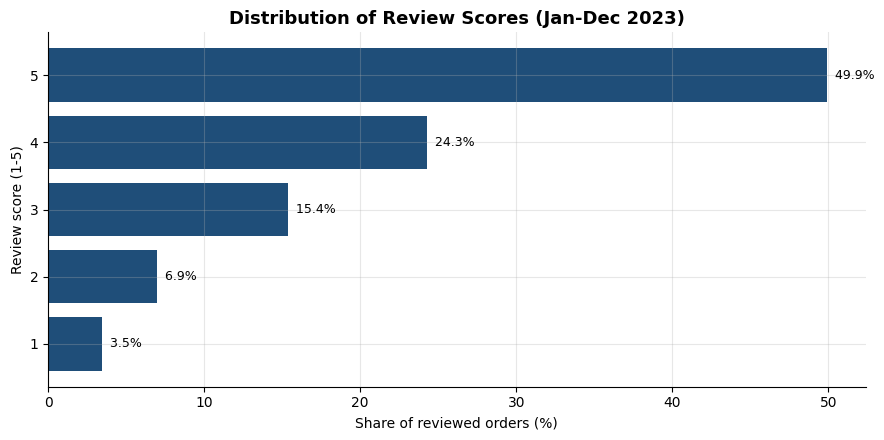

In [9]:
# Review-score distribution.
distribution = bm.review_score_distribution(current)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(distribution.index.astype(int).astype(str),
        distribution.values * 100, color=COLOR_PRIMARY)
ax.set_title(f"Distribution of Review Scores ({DATE_RANGE})",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Share of reviewed orders (%)")
ax.set_ylabel("Review score (1-5)")
for y, value in enumerate(distribution.values):
    ax.text(value * 100, y, f"  {value*100:.1f}%", va="center", fontsize=9)
plt.tight_layout()
plt.show()

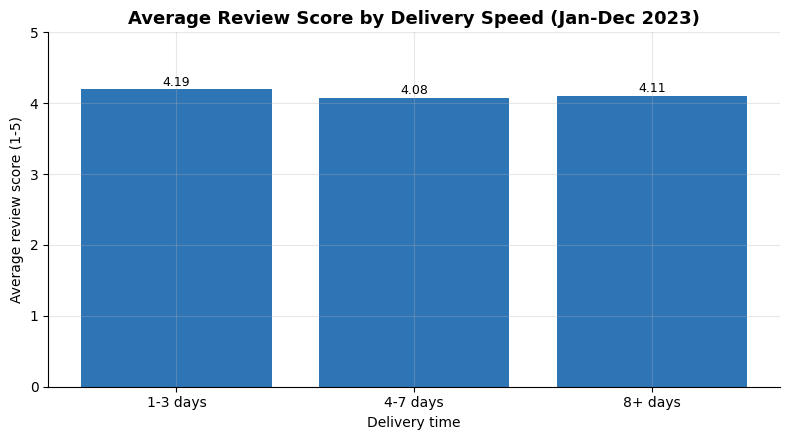

In [10]:
# Average review score by delivery-speed bucket.
by_bucket = bm.review_by_delivery_bucket(current)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(by_bucket["delivery_bucket"], by_bucket["review_score"], color=COLOR_ACCENT)
ax.set_title(f"Average Review Score by Delivery Speed ({DATE_RANGE})",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Delivery time")
ax.set_ylabel("Average review score (1-5)")
ax.set_ylim(0, 5)
for x, value in enumerate(by_bucket["review_score"]):
    ax.text(x, value + 0.05, f"{value:.2f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

<a id="5"></a>
## 5. Summary of Observations

The cell below prints the full KPI summary for the configured period. Key
takeaways for the default **2023 vs 2022** analysis:

- **Revenue was essentially flat year-over-year** (~$3.36M, **−2.5%** vs 2022),
  driven by a slight decline in order volume (**−2.4%**) while average order
  value held steady (**−0.1%**). Month-over-month growth averaged roughly flat,
  with a notable dip in October.
- **Electronics and home & garden dominate revenue**, together making up the
  large majority of sales — the business is concentrated in a few categories.
- **California, Texas and Florida are the largest markets**, mirroring overall
  US population centres.
- **Customers are broadly satisfied** (average review **4.10 / 5**, with ~74%
  rating 4+). Orders delivered within **1-3 days score highest (4.19)**, so
  faster delivery is associated with better reviews — a lever for improving
  satisfaction.

Re-run the notebook with a different `ANALYSIS_YEAR`, `COMPARISON_YEAR` or
`ANALYSIS_MONTH` to regenerate every metric and chart for another period.


In [11]:
print(bm.format_summary(bm.build_summary(current, previous), PERIOD_LABEL))

BUSINESS METRICS SUMMARY - 2023

REVENUE PERFORMANCE:
  Total Revenue:       $3,360,294.74
  Total Orders:        4,635
  Average Order Value: $724.98
  Revenue Growth:      -2.5%
  Orders Growth:       -2.4%
  AOV Growth:          -0.1%

CUSTOMER EXPERIENCE:
  Average Review Score: 4.10/5.0
  High Satisfaction (4+): 74.2%
  Average Delivery Time:  8.0 days
  Fast Delivery (<=3 days): 7.2%
